# Tutorial 12: Basic Auto Encoders

## Objectives

The primary goals of this tutorial are to:

* Understand the architecture of basic auto encoders.
* Learn how to implement a basic auto encoder using TensorFlow/Keras.
* Visualize the results of the reconstruction process.

---

## Discussion: What is an Autoencoder?

An autoencoder is a type of artificial neural network used to learn efficient codings of unlabeled data. The network is designed to compress the input into a lower-dimensional code and then reconstruct the output from this representation. It consists of two main components:

1. **Encoder:** This part of the network compresses the input into a smaller, dense representation called the latent space.
2. **Decoder:** This part attempts to reconstruct the original input as closely as possible from the compressed representation provided by the encoder.

In this tutorial, I use convolutional layers, making this a **Convolutional Autoencoder**, which is particularly effective for image data.

---

## Import Libraries

I will start by importing the necessary libraries for building the model, processing data, and visualization.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

---

## Load Data Set

The MNIST dataset contains grayscale images of handwritten digits (28x28 pixels). We will load this dataset, normalize the pixel values to a range of [0, 1], and reshape the data to include the channel dimension to ensure compatibility with Convolutional Neural Networks (CNNs).

In [2]:
# Load the dataset (MNIST)
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Add an extra dimension for the channel (since MNIST is grayscale)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


---

## Define the Autoencoder Model

My architecture uses convolutional layers to extract spatial features and max-pooling layers to reduce dimensions in the encoder. The decoder uses upsampling and convolutional layers to reconstruct the image back to its original 28x28 shape.

In [3]:
# Define the autoencoder architecture
input_img = layers.Input(shape=(28, 28, 1)) # Image size is 28x28 with 1 color channel

# Encoder part
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder part
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Construct the full model
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

---

## Discussion: Training Strategy

Unlike standard classification tasks, the "labels" in autoencoder training are the input images themselves. The model minimizes the **reconstruction error**, which is the difference between the original input and the reconstructed output. By setting `x_train` as both the input and the target, the model learns to capture the most significant features of the data.

---

## Train the Autoencoder

I will now train the model using the MNIST training set.

In [4]:
# Train the autoencoder
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 163s 343ms/step - loss: 0.1069 - val_loss: 0.0737
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 210s 360ms/step - loss: 0.0722 - val_loss: 0.0699
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 335ms/step - loss: 0.0697 - val_loss: 0.0683
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 155s 330ms/step - loss: 0.0683 - val_loss: 0.0672
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 161s 342ms/step - loss: 0.0674 - val_loss: 0.0665
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 334ms/step - loss: 0.0668 - val_loss: 0.0660
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 156s 333ms/step - loss: 0.0662 - val_loss: 0.0656
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 336ms/step - loss: 0.0658 - val_loss: 0.0650
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 205s 344ms/step - loss: 0.0654 - val_loss: 0.0650
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 335ms/step - loss: 0.0651 - val_loss: 0.0645
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 344ms/step - loss: 0.0648 - val_loss: 0.0642
Epoch 12

---

## Visualize the Results

After training, I compare the original input images from the test set with the images reconstructed by the autoencoder to see how much information was preserved.

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step


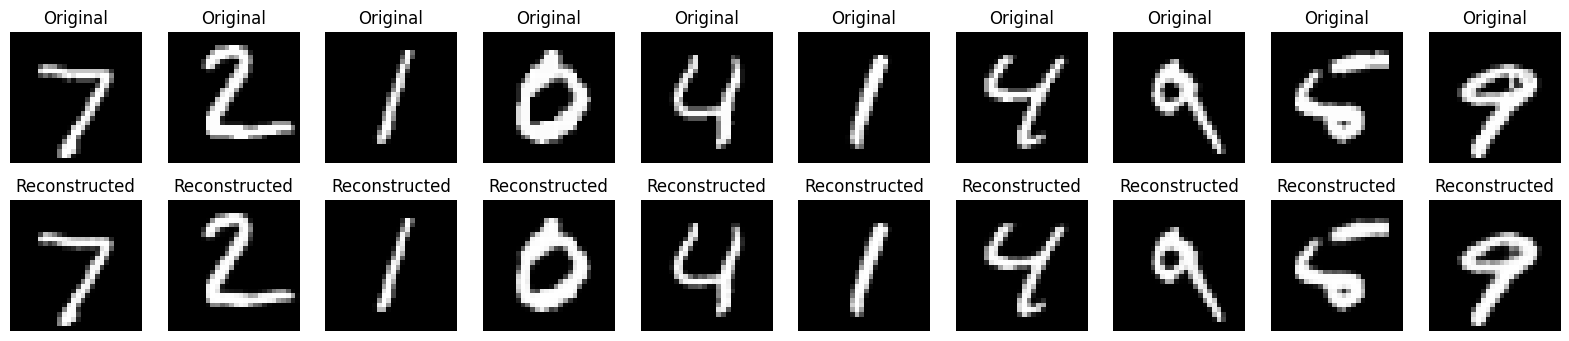

In [5]:
# Get reconstructed images
decoded_imgs = autoencoder.predict(x_test)

# Visualize the original and reconstructed images side by side
n = 10  # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
    plt.title("Original")

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
    plt.title("Reconstructed")
plt.show()

---
# Task: Improving the Model Architecture
In this version, we will increase the depth of the network. Adding more convolutional layers allows the model to learn more complex spatial hierarchies.


In [6]:
# Improved Autoencoder Architecture
input_img = layers.Input(shape=(28, 28, 1))

# Deeper Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Deeper Decoder
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu')(x) # Note: 'valid' padding to adjust shape
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Compile and summary
autoencoder_improved = models.Model(input_img, decoded)
autoencoder_improved.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder_improved.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)

# Discussion: Why Deeper Architectures?
**Feature Extraction**: By adding more layers, the encoder can move from identifying simple edges to recognizing more complex shapes and digits.

**Latent Space Compression:** A deeper bottleneck (latent space) forces the model to be more selective about which information it preserves, often leading to better "denoising" capabilities and cleaner reconstructions.

**Transposed Convolutions:** While the tutorial uses UpSampling2D followed by Conv2D, another way to improve quality is using Conv2DTranspose layers, which learn their own upscaling weights.

In [7]:
# Train the improved model
history = autoencoder_improved.fit(x_train, x_train,
                                   epochs=20,
                                   batch_size=128,
                                   shuffle=True,
                                   validation_data=(x_test, x_test))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 103s 212ms/step - loss: 0.1895 - val_loss: 0.1337
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 213ms/step - loss: 0.1251 - val_loss: 0.1176
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 208ms/step - loss: 0.1149 - val_loss: 0.1119
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 212ms/step - loss: 0.1095 - val_loss: 0.1062
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 212ms/step - loss: 0.1059 - val_loss: 0.1030
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 212ms/step - loss: 0.1031 - val_loss: 0.1015
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - loss: 0.1010 - val_loss: 0.0991
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 213ms/step - loss: 0.0992 - val_loss: 0.0981
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 212ms/step - loss: 0.0976 - val_loss: 0.0958
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 211ms/step - loss: 0.0964 - val_loss: 0.0947
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 210ms/step - loss: 0.0952 - val_loss: 0.0935
Epoch 12/20


# Visualizing Model Convergence

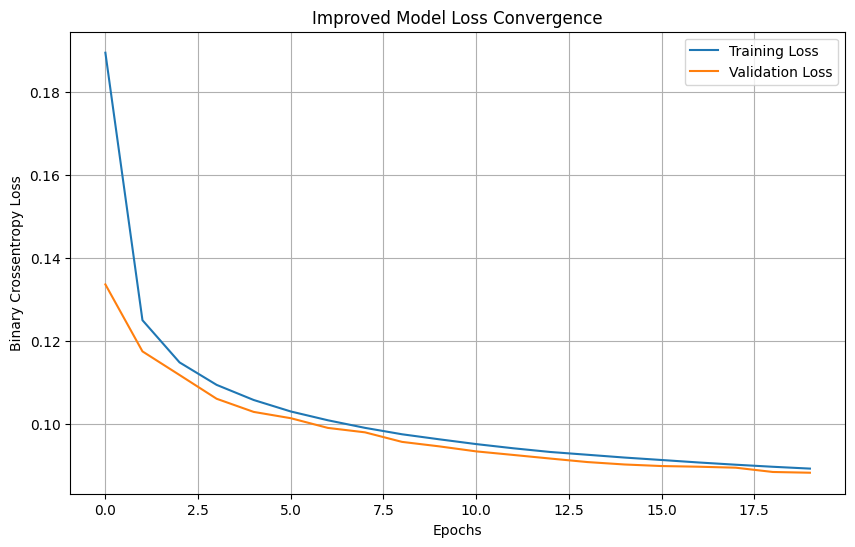

In [8]:
# Plotting the loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Improved Model Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


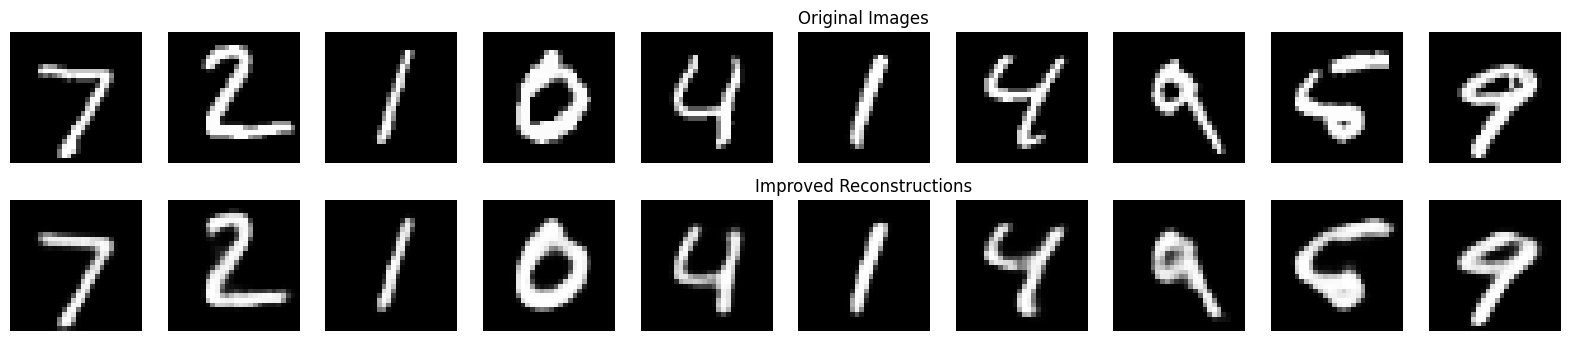

In [9]:
# Get reconstructed images from the improved model
decoded_imgs_improved = autoencoder_improved.predict(x_test)

# Visualize the original and improved reconstructed images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
    if i == 5: plt.title("Original Images")

    # Reconstructed (Improved)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_improved[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
    if i == 5: plt.title("Improved Reconstructions")
plt.show()